<a href="https://colab.research.google.com/github/Dustyluc123/machine_learning_SERS_1ccpg/blob/main/SERS_aula6_ML_energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Exercícos



Treinar um modelo preditivo de classificação de estabilidade de uma rede elétrica

Fonte: https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
#Algoritimoes do Sklearn para classificação
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
#metricas para clasificação
from sklearn.metrics import accuracy_score # acurácia
from sklearn.metrics import confusion_matrix # indentificação de onde o modelo errou
from sklearn.metrics import classification_report #resumo das metricas

##Carregar os dadods e criar um dataframe


In [3]:
dados = pd.read_csv('https://raw.githubusercontent.com/Dustyluc123/machine_learning_SERS_1ccpg/refs/heads/main/Data_for_UCI_named.csv')

In [4]:
dados.head()


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


##Análise Exploratória

In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [6]:
#Somente estatisticas de atributos categóricoes
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [7]:
#Somente estatísticas de atributos númericoes
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [8]:
#Checando a quantidade de classe da coluna alvo(stabf)
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [9]:
#Checandoa. quantidade de valores de cada classe da coluna alvo (stabf)
dados['stabf'].value_counts()



,count
stabf,
unstable,6380
stable,3620


##Separção de dados:
entrada (features) ---> X

Saída(target) ---> y

In [10]:
# Features
X = dados.drop(['stab','stabf'], axis = 1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [11]:
#Variavel alvo(target)
y = dados['stabf']
y.head()

,stabf
0,unstable
1,stable
2,unstable
3,unstable
4,unstable


In [12]:
y = y.map({'stable': 'estavel', "unstable": "instavel"})

##Separação de dados de treino e teste

In [13]:
#X_train, X_test, y_train, y_test
#Amostra aleatória para treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)
#Amostra (balanceamento de classes)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17, stratify=y)

## Treinamento e geração das previsões do modelo


In [14]:
#Instanciando o modelo
modelo_LR = LogisticRegression()

modelo_LR.fit(X_train, y_train)

y_predict = modelo_LR.predict(X_test)
y_predict


array(['instavel', 'instavel', 'instavel', ..., 'estavel', 'instavel',
       'instavel'], dtype=object)

##Avaliação do modelo

In [15]:
#acuracia
acuracia = 100 * accuracy_score(y_test, y_predict)
print(f'A Acurácia do modelo baseado em regrassão logística é: {acuracia:.2f}%')

A Acurácia do modelo baseado em regrassão logística é: 82.45%


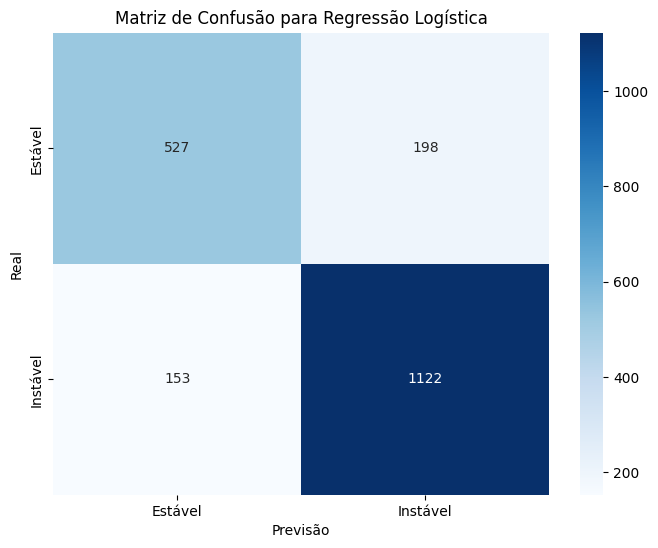

In [16]:


# Calcular a matriz de confusão
matriz_confusao = confusion_matrix(y_test, y_predict)

# Matriz de confusão usando o seaborn e matplotlib
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
xticklabels=['Estável', 'Instável'], yticklabels=['Estável', 'Instável'])
plt.xlabel('Previsão')

plt.ylabel('Real')
plt.title('Matriz de Confusão para Regressão Logística')
plt.show()

In [17]:
  #classfication report
  report = classification_report(y_test, y_predict)
  print(report)

              precision    recall  f1-score   support

     estavel       0.78      0.73      0.75       725
    instavel       0.85      0.88      0.86      1275

    accuracy                           0.82      2000
   macro avg       0.81      0.80      0.81      2000
weighted avg       0.82      0.82      0.82      2000



##Exercício 2

Treinar um modelo de regressão linear para prever os valores da coluna 'stab'. sklearn ----> LinearRegression Para essa tarefa é necessário que o grupo encontre as features que possuam maior correlação linear com a variável alvo 'stab'. Dica: crie uma matriz de correlação usando heatmap com o matplotlib e/ou seaborn

y ---> target ---> dados da coluna 'stab' X ---> features ------> dataframe com as features com maior correlação linear com a coluna 'stab' ----> no mínimo 3 atributos

Métricas: Coeficiente de determinação R2 MAE MSE

Gerar os gráficos de correlação entre 'stab' e as variáveis de entrada. Gerar o gráfico Real x Previsto

In [18]:
from sklearn.linear_model import LinearRegression


In [19]:
# Instanciando o modelo_LR com base na classe LinearRegression
modelo_LR = LinearRegression()

In [20]:

dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [21]:

# Features (dataframe X) ----> 3 atributos que tenham maior correlação linear com a
# coluna alvo (target) ---> 'stab'

Para essa tarefa é necessário que o grupo encontre as features que possuam maior correlação linear com a variável alvo 'stab'. Dica: crie uma matriz de correlação usando heatmap com o matplotlib e/ou seaborn a partir de todos os atributos do dataframe 'dados'

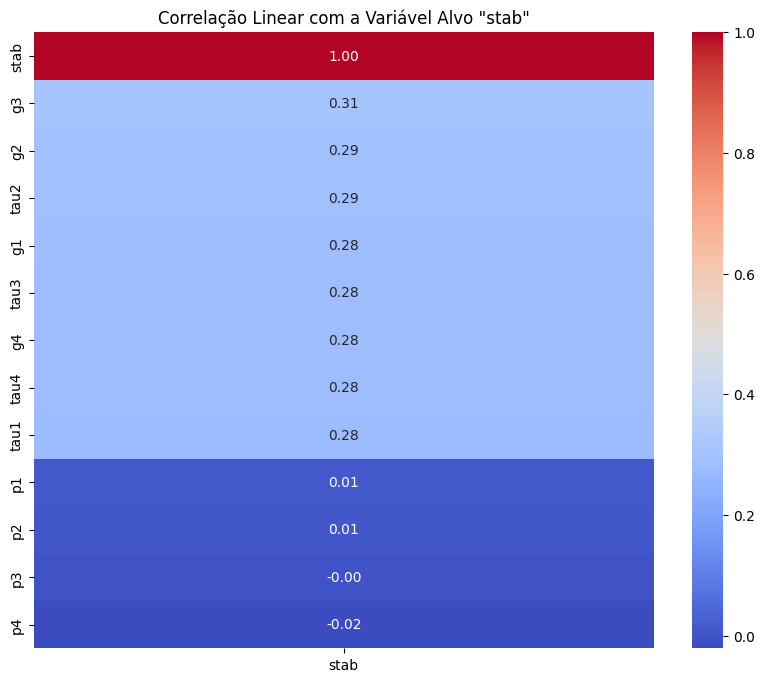

Correlações com a variável 'stab':
stab    1.000000
g3      0.308235
g2      0.293601
tau2    0.290975
g1      0.282774
tau3    0.280700
g4      0.279214
tau4    0.278576
tau1    0.275761
p1      0.010278
p2      0.006255
p3     -0.003321
p4     -0.020786
Name: stab, dtype: float64


In [22]:
# Calculate the correlation matrix
correlacao_matrix = dados.corr(numeric_only=True)

# Get correlations with 'stab' variable
correlacao_stab = correlacao_matrix['stab'].sort_values(ascending=False)

# Plotting the heatmap of correlations with 'stab'
plt.figure(figsize=(10, 8))
sns.heatmap(correlacao_stab.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação Linear com a Variável Alvo "stab"')
plt.show()

print("Correlações com a variável 'stab':")
print(correlacao_stab)

Gere os gráficos de dispersão das 3 variáveis de maior correlação em x e a variável alvo 'stab' em y. Plote também a reta de regressão. Apresente os gráficos lado a lado em uma imagem. Fundo preto.

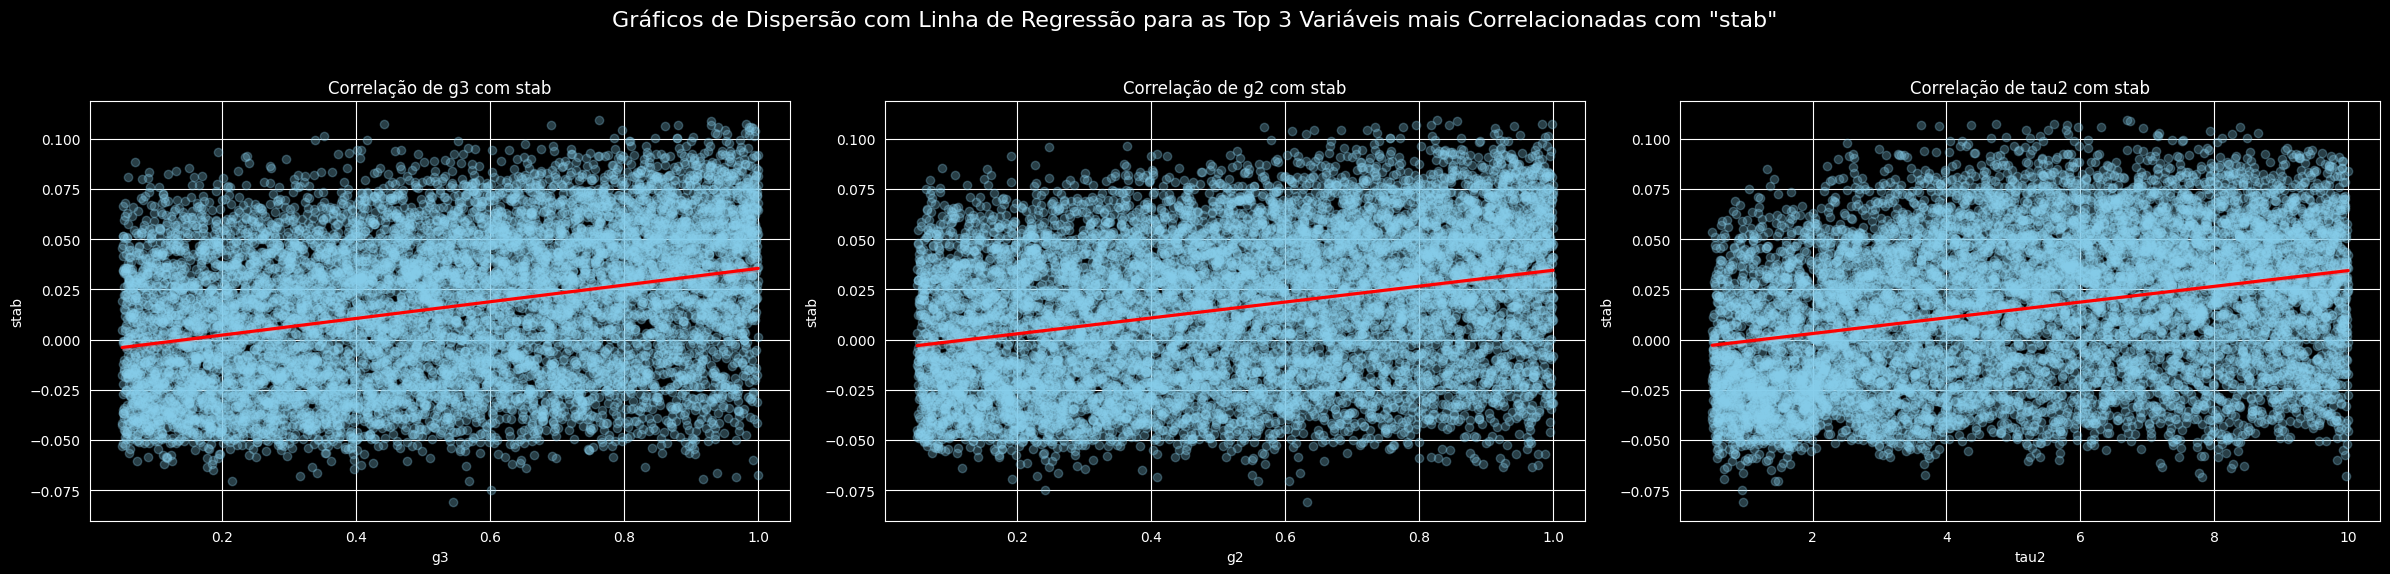

In [23]:

# Get the top 3 correlated features with 'stab' (excluding 'stab' itself)
top_3_features = correlacao_stab[1:4].index.tolist()

# Set the style for the plots and background color
sns.set_style("darkgrid", {"axes.facecolor": "black", "figure.facecolor": "black"})
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Gráficos de Dispersão com Linha de Regressão para as Top 3 Variáveis mais Correlacionadas com "stab"', color='white', fontsize=16)

for i, feature in enumerate(top_3_features):
    sns.regplot(x=feature, y='stab', data=dados, ax=axes[i], scatter_kws={'alpha':0.3, 'color':'skyblue'}, line_kws={'color':'red'})
    axes[i].set_title(f'Correlação de {feature} com stab', color='white')
    axes[i].set_xlabel(feature, color='white')
    axes[i].set_ylabel('stab', color='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

# Reset default style if needed for subsequent plots
sns.set_style("darkgrid")
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'

In [24]:

dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [25]:
# Dados de entrada do modelo (X):
X = dados[['tau2', 'g2', 'g3']]
X.head()

,tau2,g2,g3
0,3.079885,0.859578,0.887445
1,4.902524,0.862414,0.562139
2,8.848428,0.766689,0.839444
3,7.669600,0.976744,0.929381
4,7.608772,0.455450,0.656947


In [26]:

# Target
y = dados['stab']
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


In [27]:
# Separando dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

In [28]:
X_train.shape


(8000, 3)

In [29]:
y_train.shape

(8000,)

In [30]:

y.head()


,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


In [31]:
# Treinamento do modelo de regressão linear
modelo_LR.fit(X_train, y_train)

LinearRegression()

In [32]:
y_test.values

array([ 0.01146308,  0.04195828,  0.05767316, ..., -0.04395929,
        0.03369772,  0.03513459])

In [33]:

y_test[:50]


,stab
2688,0.011463
233,0.041958
9099,0.057673
8652,0.011312
2842,0.002803
283,0.030228
7673,-0.020711
1435,0.076084
8641,0.064983
9584,0.044900


In [34]:

# Gerando previsões
y_predict = modelo_LR.predict(X_test)
y_predict[:50]

array([ 0.02836254,  0.01491935,  0.01758781,  0.00557947, -0.00152692,
        0.00370801,  0.00607375,  0.02169718,  0.0055979 ,  0.01720782,
       -0.00894882,  0.03726513, -0.02117957,  0.0052061 ,  0.03989881,
        0.05255102,  0.02100049,  0.0360181 ,  0.01824608,  0.03023555,
        0.00952129, -0.02415203,  0.02188019,  0.00713168,  0.02055473,
        0.0065953 ,  0.00856773,  0.03413339,  0.01360304, -0.00475366,
        0.01860118,  0.00460138, -0.02415915,  0.01177945,  0.0313005 ,
       -0.02623412,  0.03292247,  0.01925688,  0.0412256 ,  0.01290649,
        0.03636565,  0.02181991, -0.01101281,  0.03839857, -0.00045866,
        0.00047298, -0.01898246,  0.05211772, -0.0036266 ,  0.03484327])

In [35]:
# Métricas:
# Coeficiente de determinação R2 (R quadrado)
# MAE: erro médio absoluto
# MSE: erro médio quadrático
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [36]:
# Melhor modelo de regressão:
# R2 precisa ser alto
# Os erros precisam ser baixos

In [37]:
print(f'Coeficiente de determinação R2: {r2_score(y_test, y_predict):.2f}')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_test, y_predict):.2f}')
print(f'Erro médio quadrático (MSE): {mean_squared_error(y_test, y_predict):.2f}')

Coeficiente de determinação R2: 0.27
Erro médio absoluto (MAE): 0.03
Erro médio quadrático (MSE): 0.00


In [38]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [39]:
#Moledo 2 Utilizar todas as variveis que posseume correleção linear com
#A coluna 'stap' (target)---> todas exceto stanf, stah e